# SAMSum dataset exploration

This notebook examines the standard SAMSum splits before any modelling. It uses whitespace-delimited word counts as a simple, reproducible length proxy; these are not the later model-tokenizer lengths.

In [14]:
import sys
!{sys.executable} -m pip install torch datasets numpy pandas matplotlib tqdm rouge-score

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.8/124.1 MB 3.4 MB/s eta 0:00:37
    --------------------------------------- 1.8/124.1 MB 4.4 MB/s eta 0:00:28
   - -------------------------------------- 3.1/124.1 MB 5.3 MB/s eta 0:00:23
   - -------------------------------------- 4.5/124.1 MB 5.4 MB/s eta 0:00:23
   - ------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.17.0 requires numpy<2.0.0,>=1.26.0; python_version >= "3.12", but you have numpy 2.5.1 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data import DATASET_NAME, load_samsum

dataset = load_samsum()
print(f'Dataset: {DATASET_NAME}')
dataset

c:\Users\Omar\AppData\Local\Programs\Python\Python312\Lib\importlib\__init__.py:90: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.5.1)
  return _bootstrap._gcd_import(name[level:], package, level)


Dataset: knkarthick/samsum


DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})

## Split sizes and schema

In [16]:
for split_name, split in dataset.items():
    print(f'{split_name:>10}: {len(split):,} examples | columns: {split.column_names}')

     train: 14,731 examples | columns: ['id', 'dialogue', 'summary']
validation: 818 examples | columns: ['id', 'dialogue', 'summary']
      test: 819 examples | columns: ['id', 'dialogue', 'summary']


## Dialogue–summary examples

In [17]:
for index in [0, 1, 20]:
    example = dataset['train'][index]
    print(f"Example {index} (id={example['id']})")
    print('Dialogue:')
    print(example['dialogue'])
    print('\nReference summary:')
    print(example['summary'])
    print('\n' + '=' * 80 + '\n')

Example 0 (id=13818513)
Dialogue:
Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you tomorrow :-)

Reference summary:
Amanda baked cookies and will bring Jerry some tomorrow.


Example 1 (id=13728867)
Dialogue:
Olivia: Who are you voting for in this election? 
Oliver: Liberals as always.
Olivia: Me too!!
Oliver: Great

Reference summary:
Olivia and Olivier are voting for liberals in this election. 


Example 20 (id=13716048)
Dialogue:
Ashley: Guys, you have to read this book!  <file_photo>
Marcus: Why, what's so special about it?
Erin: I think I've already heard about it from someone. Is it really that good?
Ashley: It's the best thing I've ever read! Completely life-changing! It's opened my eyes to a lot of things.
Seamus: Sorry, but I don't like books that are written to change my life. I prefer books that are simply fun to read :P
Marcus: I get what you mean. I feel like some authors are so concentrated on making their books full of wisdom that they comp

## Length statistics

In [8]:
def word_count(text):
    return len(text.split())

def describe_lengths(values):
    values = sorted(values)
    n = len(values)
    def percentile(p):
        return values[round((n - 1) * p)]
    return {
        'min': values[0],
        'mean': sum(values) / n,
        'median': percentile(0.50),
        'p95': percentile(0.95),
        'max': values[-1],
    }

lengths = {}
for split_name, split in dataset.items():
    dialogue_words = [word_count(text) for text in split['dialogue']]
    summary_words = [word_count(text) for text in split['summary']]
    lengths[split_name] = {'dialogue': dialogue_words, 'summary': summary_words}
    print(f'\n{split_name.upper()} (whitespace words)')
    for field, values in lengths[split_name].items():
        stats = describe_lengths(values)
        print(f"  {field:8} min={stats['min']:>4}  mean={stats['mean']:>6.1f}  "
              f"median={stats['median']:>4}  p95={stats['p95']:>4}  max={stats['max']:>4}")


TRAIN (whitespace words)
  dialogue min=   7  mean=  93.8  median=  73  p95= 237  max= 803
  summary  min=   1  mean=  20.3  median=  18  p95=  43  max=  64

VALIDATION (whitespace words)
  dialogue min=  10  mean=  91.6  median=  70  p95= 225  max= 540
  summary  min=   3  mean=  20.3  median=  18  p95=  43  max=  59

TEST (whitespace words)
  dialogue min=   9  mean=  95.5  median=  74  p95= 252  max= 516
  summary  min=   3  mean=  20.0  median=  18  p95=  41  max=  58


## Length distributions

The x-axis is clipped at each plot's 99th percentile so typical examples remain visible. The printed maximums above retain information about long-tail examples.

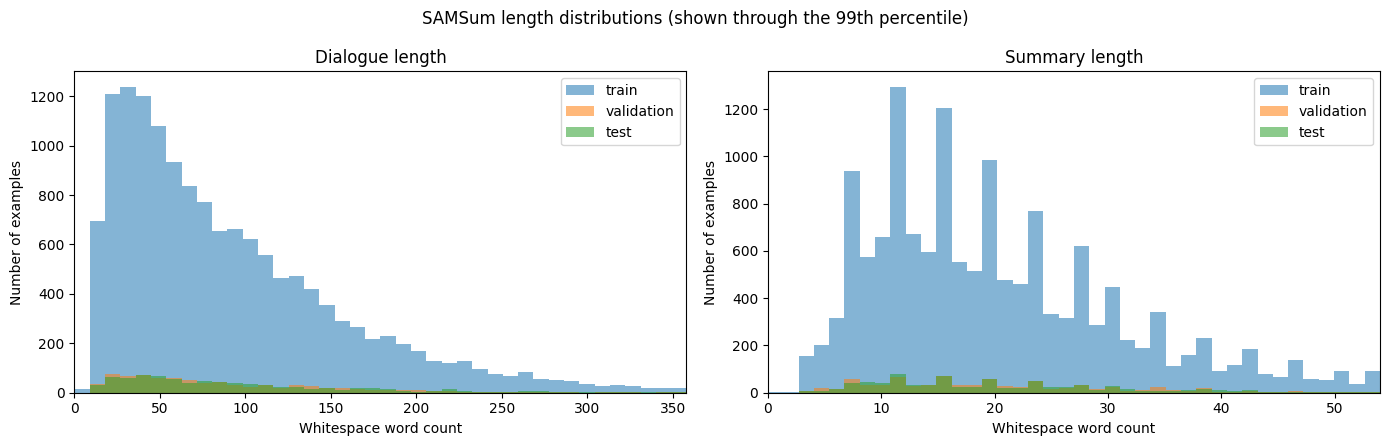

In [9]:
def percentile(values, p):
    ordered = sorted(values)
    return ordered[round((len(ordered) - 1) * p)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for axis, field, title in zip(axes, ['dialogue', 'summary'], ['Dialogue length', 'Summary length']):
    upper = max(percentile(lengths[split][field], 0.99) for split in dataset)
    for split_name in dataset:
        axis.hist(lengths[split_name][field], bins=40, range=(0, upper), alpha=0.55, label=split_name)
    axis.set(title=title, xlabel='Whitespace word count', ylabel='Number of examples', xlim=(0, upper))
    axis.legend()

fig.suptitle('SAMSum length distributions (shown through the 99th percentile)')
fig.tight_layout()
plt.show()

## Tokenizer and training-only vocabulary statistics

For the classical word-level models, text is lowercased and punctuation/symbols are retained as separate tokens. Vocabulary counts below use dialogue and summary text from **training only**; validation and test are used only to measure out-of-vocabulary (`<UNK>`) rates. Vocabulary size means the number of observed tokens retained by the threshold and excludes future special tokens such as `<PAD>`, `<UNK>`, `<SOS>`, and `<EOS>`.

In [10]:
from collections import Counter

from src.data import tokenize

sample = "Hi, Sam! I'll be there at 7:30 :)"
print(sample)
print(tokenize(sample))

Hi, Sam! I'll be there at 7:30 :)
['hi', ',', 'sam', '!', 'i', "'", 'll', 'be', 'there', 'at', '7', ':', '30', ':', ')']


In [11]:
tokenized = {
    split_name: {
        'dialogue': [tokenize(text) for text in split['dialogue']],
        'summary': [tokenize(text) for text in split['summary']],
    }
    for split_name, split in dataset.items()
}

train_token_counts = Counter()
for field in ('dialogue', 'summary'):
    for tokens in tokenized['train'][field]:
        train_token_counts.update(tokens)

print(f"Unique tokens observed in train: {len(train_token_counts):,}")
print(f"Total train tokens (dialogues + summaries): {sum(train_token_counts.values()):,}")

Unique tokens observed in train: 30,460
Total train tokens (dialogues + summaries): 2,264,472


In [21]:
def unknown_rate(split_name, vocabulary):
    tokens = (
        token
        for field in ('dialogue', 'summary')
        for example in tokenized[split_name][field]
        for token in example
    )
    total = unknown = 0
    for token in tokens:
        total += 1
        unknown += token not in vocabulary
    return 100 * unknown / total

thresholds = [1, 2, 3, 5]
print(f"{'min_freq':>8}  {'vocab size':>10}  {'validation UNK %':>18}  {'test UNK %':>10}")
print('-' * 58)
for min_freq in thresholds:
    vocabulary = {token for token, count in train_token_counts.items() if count >= min_freq}
    validation_unk = unknown_rate('validation', vocabulary)
    test_unk = unknown_rate('test', vocabulary)
    print(f'{min_freq:>8}  {len(vocabulary):>10,}  {validation_unk:>17.2f}%  {test_unk:>9.2f}%')

min_freq  vocab size    validation UNK %  test UNK %
----------------------------------------------------------
       1      30,460               1.21%       1.24%
       2      20,893               1.55%       1.56%
       3      16,035               1.92%       1.87%
       5      11,970               2.45%       2.44%


## Tokenizer-based lengths and truncation rates

These lengths exclude any future start/end tokens. A sequence is counted as truncated only when its tokenized length is greater than the stated maximum.

In [12]:
token_lengths = {
    split_name: {field: [len(tokens) for tokens in examples] for field, examples in fields.items()}
    for split_name, fields in tokenized.items()
}

for split_name, fields in token_lengths.items():
    print(f'\n{split_name.upper()} (tokenizer tokens)')
    for field, values in fields.items():
        stats = describe_lengths(values)
        print(f"  {field:8} min={stats['min']:>4}  mean={stats['mean']:>6.1f}  "
              f"median={stats['median']:>4}  p95={stats['p95']:>4}  max={stats['max']:>4}")


TRAIN (tokenizer tokens)
  dialogue min=  10  mean= 129.5  median= 102  p95= 324  max=1047
  summary  min=   1  mean=  24.2  median=  21  p95=  51  max=  77

VALIDATION (tokenizer tokens)
  dialogue min=  15  mean= 126.3  median=  98  p95= 303  max= 693
  summary  min=   4  mean=  24.2  median=  21  p95=  51  max=  70

TEST (tokenizer tokens)
  dialogue min=  14  mean= 132.1  median= 102  p95= 339  max= 681
  summary  min=   4  mean=  23.9  median=  22  p95=  49  max=  77


In [11]:
def truncation_rate(lengths, maximum):
    return 100 * sum(length > maximum for length in lengths) / len(lengths)

def print_truncation_table(field, maximums):
    print(f'\n{field.title()} truncation rate (%)')
    print(f"{'max tokens':>10}  {'train':>8}  {'validation':>11}  {'test':>8}")
    print('-' * 44)
    for maximum in maximums:
        rates = [truncation_rate(token_lengths[split][field], maximum) for split in ('train', 'validation', 'test')]
        print(f'{maximum:>10}  {rates[0]:>7.2f}%  {rates[1]:>10.2f}%  {rates[2]:>7.2f}%')

print_truncation_table('dialogue', [200, 250, 300])
print_truncation_table('summary', [40, 50, 60])


Dialogue truncation rate (%)
max tokens     train   validation      test
--------------------------------------------
       200    19.06%       17.73%    19.66%
       250    11.16%       10.15%    11.84%
       300     6.45%        5.26%     7.57%

Summary truncation rate (%)
max tokens     train   validation      test
--------------------------------------------
        40    12.41%       12.47%    11.72%
        50     5.20%        5.13%     4.27%
        60     1.64%        1.47%     1.34%


In [13]:
from src.data import load_samsum
from src.preprocessing import (
    build_samsum_vocabulary,
    SAMSumDataset,
    create_dataloader,
)

splits = load_samsum()
vocabulary = build_samsum_vocabulary(splits["train"])

train_dataset = SAMSumDataset(splits["train"], vocabulary)
train_loader = create_dataloader(train_dataset, batch_size=4, shuffle=True)

batch = next(iter(train_loader))

In [14]:
ids = batch["dialogue_ids"][0]

tokens = [vocabulary.itos[i.item()] for i in ids]

print(tokens)

['<SOS>', 'jillian', ':', 'i', 'lost', 'my', 'new', 'pen', ',', 'i', 'think', 'i', 'left', 'it', 'at', 'your', 'place', 'near', 'the', 'computer', '.', 'can', 'you', 'check', 'it', 'please', '?', 'galard', ':', 'no', 'problem', ',', 'as', 'soon', 'as', 'i', "'", 'm', 'home', 'i', 'will', 'check', '.', 'jillian', ':', 'cool', ',', 'thanks', '.', 'i', 'have', 'my', 'notes', 'there', 'and', 'i', 'need', 'them', '.', '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>'

In [15]:
ids = batch["summary_ids"][0]

tokens = [vocabulary.itos[i.item()] for i in ids]

print(tokens)

['<SOS>', 'jillian', 'has', 'lost', 'her', 'pen', '-', 'drive', 'with', 'her', 'notes', '.', 'galard', 'will', 'check', 'if', 'jillian', "'", 's', 'pen', '-', 'drive', 'is', 'at', 'his', 'place', '.', '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']


## Vanilla Seq2Seq Model Verification

This is a forward-pass smoke test only. It reuses the shared training vocabulary and `train_loader` created above; no loss, optimization, training, evaluation, or decoding strategy is involved.

In [16]:
import torch

from src.models import Decoder, Encoder, Seq2Seq

encoder = Encoder(
    vocab_size=len(vocabulary),
    pad_id=vocabulary.pad_id,
    embedding_dim=256,
    hidden_dim=256,
    embedding_dropout=0.2,
)
decoder = Decoder(
    vocab_size=len(vocabulary),
    pad_id=vocabulary.pad_id,
    embedding_dim=256,
    hidden_dim=256,
    embedding_dropout=0.2,
)
model = Seq2Seq(encoder, decoder)

print(model)
trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(f'\nTrainable parameters: {trainable_parameters:,}')

batch = next(iter(train_loader))
dialogue_ids = batch['dialogue_ids']
summary_ids = batch['summary_ids']
dialogue_lengths = batch['dialogue_lengths']

model.eval()
with torch.no_grad():
    encoder_hidden, encoder_cell = model.encoder(dialogue_ids, dialogue_lengths)
    output_logits = model(
        dialogue_ids,
        summary_ids,
        source_lengths=dialogue_lengths,
        teacher_forcing_ratio=0.5,
    )

print(f'\nDialogue input shape:       {tuple(dialogue_ids.shape)}')
print(f'Summary target shape:       {tuple(summary_ids.shape)}')
print(f'Model output shape:         {tuple(output_logits.shape)}')
print(f'Encoder hidden-state shape: {tuple(encoder_hidden.shape)}')
print(f'Encoder cell-state shape:   {tuple(encoder_cell.shape)}')

assert output_logits.size(-1) == len(vocabulary)
print(f'\nVerified: output vocabulary dimension ({output_logits.size(-1):,}) equals vocabulary size ({len(vocabulary):,}).')

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(20897, 256, padding_idx=0)
    (embedding_dropout): Dropout(p=0.2, inplace=False)
    (lstm): LSTM(256, 256, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(20897, 256, padding_idx=0)
    (embedding_dropout): Dropout(p=0.2, inplace=False)
    (lstm): LSTM(256, 256, batch_first=True)
    (output_projection): Linear(in_features=256, out_features=20897, bias=True)
  )
)

Trainable parameters: 17,122,465

Dialogue input shape:       (4, 302)
Summary target shape:       (4, 30)
Model output shape:         (4, 29, 20897)
Encoder hidden-state shape: (1, 4, 256)
Encoder cell-state shape:   (1, 4, 256)

Verified: output vocabulary dimension (20,897) equals vocabulary size (20,897).


For this batch, `dialogue_ids` has shape `(batch, longest_dialogue)` and `summary_ids` has shape `(batch, longest_summary)`; both include boundary tokens and may include right padding. The encoder states have shape `(layers, batch, hidden_size)`, which is `(1, batch, 256)` here. `output_logits` has shape `(batch, longest_summary - 1, vocabulary_size)`: position zero predicts the token after `<SOS>`, so its time dimension aligns with `summary_ids[:, 1:]`. Each final-dimension value is an unnormalized score for one vocabulary token.